In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from arch import arch_model
from arch.unitroot import PhillipsPerron
from mgarch import mgarch
import pickle

In [10]:
with open("garch_results.pkl", "rb") as f:
    cond_vol_df = pickle.load(f)

In [11]:
cond_vol_df

,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2017-11-24,16.507313,18.266865,2.155515,2.118252,0.389288,1.287028
2017-12-01,16.701614,18.147307,1.974381,1.938315,0.378420,1.283179
2017-12-08,16.876909,18.344621,1.802223,1.782685,0.373350,1.268553
2017-12-15,17.042520,18.519874,1.683604,1.660264,0.358625,1.256976
2017-12-22,17.242495,18.339653,1.572068,1.553096,0.363641,1.323936
...,...,...,...,...,...,...
2025-12-05,5.221141,7.040877,2.020118,2.079538,0.463404,1.437077
2025-12-12,5.191871,7.167048,1.861117,1.907463,0.501521,1.520444
2025-12-19,5.274682,7.342158,1.926543,1.920141,0.476537,1.511580


In [6]:
#Check Stationarity (ADF)
from statsmodels.tsa.stattools import adfuller
import pandas as pd

results = []

for col in cond_vol_df.columns:
    adf_result = adfuller(cond_vol_df[col])

    test_stat = adf_result[0]
    p_value = adf_result[1]

    if p_value < 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    elif p_value < 0.10:
        sig = "*"
    else:
        sig = ""

    results.append([col, test_stat, p_value, sig])

df_adf = pd.DataFrame(results,
                      columns=["Asset", "ADF Statistic", "p-value", "Sig"])

df_adf["ADF Statistic"] = df_adf["ADF Statistic"].round(4)
df_adf["p-value"] = df_adf["p-value"].round(6)

df_adf

,Asset,ADF Statistic,p-value,Sig
0,BTC,-2.0334,0.272112,
1,ETH,-2.2285,0.196062,
2,SP500,-6.2239,0.000000,***
3,VTI,-6.2222,0.000000,***
4,AGG,-5.4366,0.000003,***
5,TLT,-4.0378,0.001225,***


In [7]:
cond_vol_df = np.log(cond_vol_df).diff().dropna() * 100
cond_vol_df

,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2017-12-01,1.170181,-0.656657,-8.777444,-8.877209,-2.831458,-0.299449
2017-12-08,1.044101,1.081419,-9.123422,-8.369848,-1.348823,-1.146399
2017-12-15,0.976502,0.950805,-6.808426,-7.114403,-4.023888,-0.916768
2017-12-22,1.166562,-0.977887,-6.854497,-6.672631,1.388773,5.189985
2017-12-29,-6.036601,1.174962,-5.337196,-5.960520,22.787543,14.530895
...,...,...,...,...,...,...
2025-12-05,1.477643,1.090894,-12.282077,-10.586649,-1.400118,-0.484049
2025-12-12,-0.562176,1.776116,-8.197910,-8.637170,7.904763,5.639117
2025-12-19,1.582434,2.413887,3.455060,0.662460,-5.110166,-0.584695


In [212]:
# edit to the above, remove if necessary
# BTC and ETH → log returns
for col in ['BTC', 'ETH']:
    cond_vol_df[col] = np.log(cond_vol_df[col]).diff()

# Scale BTC and ETH log returns to % change
cond_vol_df['BTC'] = cond_vol_df['BTC'] * 100
cond_vol_df['ETH'] = cond_vol_df['ETH'] * 100

# Only drop rows where BTC/ETH diff created NaN
cond_vol_df.dropna(subset=['BTC', 'ETH'], inplace=True)

cond_vol_df

,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2017-12-15,-6.693508,-12.872047,-6.808426,-7.114403,-4.023888,-0.916768
2018-02-23,8.476357,81.802805,-15.776560,-14.740840,-11.944540,-3.745757
2018-05-04,5.207799,214.841773,-8.701080,-8.119637,-10.925662,-3.293961
2018-05-11,-3.934428,-130.810798,-4.878140,-5.879194,-9.511978,-2.733531
2018-06-15,-0.277304,28.351076,-8.400286,-7.362422,-3.223222,-2.850004
...,...,...,...,...,...,...
2025-07-18,-4.984906,-101.059528,-1.442750,-2.399364,0.109126,-0.792430
2025-08-22,2.153240,78.973981,-8.024559,-8.260169,-11.720506,-1.835945
2025-08-29,-51.737293,22.684661,-5.937602,-7.194278,-1.539117,-2.679994


In [8]:
#Check Stationarity (ADF)
from statsmodels.tsa.stattools import adfuller
import pandas as pd

results = []

for col in cond_vol_df.columns:
    adf_result = adfuller(cond_vol_df[col])

    test_stat = adf_result[0]
    p_value = adf_result[1]

    if p_value < 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    elif p_value < 0.10:
        sig = "*"
    else:
        sig = ""

    results.append([col, test_stat, p_value, sig])

df_adf = pd.DataFrame(results,
                      columns=["Asset", "ADF Statistic", "p-value", "Sig"])

df_adf["ADF Statistic"] = df_adf["ADF Statistic"].round(4)
df_adf["p-value"] = df_adf["p-value"].round(6)

df_adf

,Asset,ADF Statistic,p-value,Sig
0,BTC,-21.2452,0.0,***
1,ETH,-22.0682,0.0,***
2,SP500,-19.7265,0.0,***
3,VTI,-19.6461,0.0,***
4,AGG,-13.3039,0.0,***
5,TLT,-13.0788,0.0,***


In [214]:
#VECTOR AUTOREGRESSION (VAR)
cond_vol_df.index = pd.to_datetime(cond_vol_df.index)

from statsmodels.tsa.api import VAR

model = VAR(cond_vol_df)
lag_selection = model.select_order(maxlags=8)
print(lag_selection.summary())

results = model.fit(lag_selection.aic)
print(results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       31.84      31.98*   6.750e+13      31.90*
1      31.82*       32.81  6.598e+13*       32.22
2       32.04       33.87   8.241e+13       32.78
3       32.45       35.13   1.265e+14       33.54
4       32.65       36.17   1.575e+14       34.08
5       32.79       37.15   1.869e+14       34.56
6       32.96       38.18   2.360e+14       35.08
7       33.16       39.22   3.109e+14       35.62
8       33.33       40.24   4.128e+14       36.14
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 31, Mar, 2026
Time:                     18:00:15
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    32.5452
Nobs:                     125.000    

In [215]:
#GRANGER CAUSALITY TEST
from statsmodels.tsa.stattools import grangercausalitytests
import itertools
import pandas as pd

max_lag = 1 #BIC
alpha = 0.05

results_list = []

columns = cond_vol_df.columns

for y_col, x_col in itertools.permutations(columns, 2):
    test_result = grangercausalitytests(cond_vol_df[[y_col, x_col]], maxlag=max_lag, verbose=False)

    f_stat = test_result[max_lag][0]['ssr_ftest'][0]
    p_value = test_result[max_lag][0]['ssr_ftest'][1]

    # significance stars
    if p_value < 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    elif p_value < 0.10:
        sig = "*"
    else:
        sig = ""

    results_list.append([x_col, y_col, f_stat, p_value, sig])

df_results = pd.DataFrame(results_list, columns=["Cause", "Target", "F-stat", "p-value", "Sig"])

print(df_results)

    Cause Target    F-stat   p-value Sig
0     ETH    BTC  0.073057  0.787394    
1   SP500    BTC  2.592459  0.109958    
2     VTI    BTC  4.570060  0.034530  **
3     AGG    BTC  0.206663  0.650204    
4     TLT    BTC  5.078028  0.026017  **
5     BTC    ETH  0.000965  0.975273    
6   SP500    ETH  0.241720  0.623850    
7     VTI    ETH  0.171693  0.679340    
8     AGG    ETH  0.753129  0.387191    
9     TLT    ETH  0.977463  0.324783    
10    BTC  SP500  2.301715  0.131818    
11    ETH  SP500  0.054229  0.816252    
12    VTI  SP500  1.509372  0.221600    
13    AGG  SP500  0.148295  0.700840    
14    TLT  SP500  3.841511  0.052278   *
15    BTC    VTI  2.023169  0.157467    
16    ETH    VTI  0.150179  0.699040    
17  SP500    VTI  1.251384  0.265486    
18    AGG    VTI  0.009873  0.921012    
19    TLT    VTI  3.528613  0.062705   *
20    BTC    AGG  0.120615  0.728967    
21    ETH    AGG  3.038763  0.083817   *
22  SP500    AGG  4.612094  0.033725  **
23    VTI    AGG

In [216]:
from statsmodels.tsa.stattools import grangercausalitytests
import itertools
import pandas as pd

max_lag = 3 #FPE & AIC
alpha = 0.05

results_list = []

columns = cond_vol_df.columns

for y_col, x_col in itertools.permutations(columns, 2):
    test_result = grangercausalitytests(cond_vol_df[[y_col, x_col]], maxlag=max_lag, verbose=False)

    f_stat = test_result[max_lag][0]['ssr_ftest'][0]
    p_value = test_result[max_lag][0]['ssr_ftest'][1]

    # significance stars
    if p_value < 0.01:
        sig = "***"
    elif p_value < 0.05:
        sig = "**"
    elif p_value < 0.10:
        sig = "*"
    else:
        sig = ""

    results_list.append([x_col, y_col, f_stat, p_value, sig])

df_results = pd.DataFrame(results_list, columns=["Cause", "Target", "F-stat", "p-value", "Sig"])

print(df_results)

    Cause Target    F-stat   p-value Sig
0     ETH    BTC  1.524441  0.211874    
1   SP500    BTC  1.946658  0.125942    
2     VTI    BTC  2.843324  0.040821  **
3     AGG    BTC  0.495587  0.686049    
4     TLT    BTC  2.003965  0.117272    
5     BTC    ETH  0.258036  0.855473    
6   SP500    ETH  0.573910  0.633292    
7     VTI    ETH  0.498343  0.684152    
8     AGG    ETH  0.522278  0.667802    
9     TLT    ETH  0.456270  0.713374    
10    BTC  SP500  1.360985  0.258251    
11    ETH  SP500  1.675506  0.176115    
12    VTI  SP500  0.576120  0.631839    
13    AGG  SP500  0.673546  0.569955    
14    TLT  SP500  2.330687  0.077915   *
15    BTC    VTI  1.059999  0.368978    
16    ETH    VTI  2.208538  0.090819   *
17  SP500    VTI  0.461029  0.710040    
18    AGG    VTI  0.745069  0.527347    
19    TLT    VTI  2.162642  0.096192   *
20    BTC    AGG  0.132672  0.940441    
21    ETH    AGG  1.014810  0.388851    
22  SP500    AGG  1.811762  0.148878    
23    VTI    AGG

In [217]:
from statsmodels.tsa.stattools import grangercausalitytests
import itertools

max_lag = 4
alpha = 0.05

# Loop through all combinations of columns (Y, X) where Y != X
columns = cond_vol_df.columns
for y_col, x_col in itertools.permutations(columns, 2):
    print(f"\nTesting if '{x_col}' Granger-causes '{y_col}':")
    results = grangercausalitytests(cond_vol_df[[y_col, x_col]], maxlag=max_lag, verbose=False)

    for lag in range(1, max_lag + 1):
        f_test_p = results[lag][0]['ssr_ftest'][1]  # p-value of SSR F-test
        significance = "Significant" if f_test_p < alpha else "Not significant"
        symbol = "<" if f_test_p < alpha else ">"
        print(f"  Lag {lag}: p = {f_test_p:.4f} {symbol} {alpha} → {significance}")


Testing if 'ETH' Granger-causes 'BTC':
  Lag 1: p = 0.7874 > 0.05 → Not significant
  Lag 2: p = 0.8992 > 0.05 → Not significant
  Lag 3: p = 0.2119 > 0.05 → Not significant
  Lag 4: p = 0.3369 > 0.05 → Not significant

Testing if 'SP500' Granger-causes 'BTC':
  Lag 1: p = 0.1100 > 0.05 → Not significant
  Lag 2: p = 0.1581 > 0.05 → Not significant
  Lag 3: p = 0.1259 > 0.05 → Not significant
  Lag 4: p = 0.1995 > 0.05 → Not significant

Testing if 'VTI' Granger-causes 'BTC':
  Lag 1: p = 0.0345 < 0.05 → Significant
  Lag 2: p = 0.0512 > 0.05 → Not significant
  Lag 3: p = 0.0408 < 0.05 → Significant
  Lag 4: p = 0.0716 > 0.05 → Not significant

Testing if 'AGG' Granger-causes 'BTC':
  Lag 1: p = 0.6502 > 0.05 → Not significant
  Lag 2: p = 0.7254 > 0.05 → Not significant
  Lag 3: p = 0.6860 > 0.05 → Not significant
  Lag 4: p = 0.7301 > 0.05 → Not significant

Testing if 'TLT' Granger-causes 'BTC':
  Lag 1: p = 0.0260 < 0.05 → Significant
  Lag 2: p = 0.0762 > 0.05 → Not significant


## Importing Bubble Indicators

In [218]:
with open("gsadf_results.pkl", "rb") as f:
    results = pickle.load(f)

In [219]:
bubble_rows = []

for asset, res in results.items():
    for start, end in res["bubbles"]:
        bubble_rows.append({
            "asset": asset,
            "start_date": pd.to_datetime(start),
            "end_date": pd.to_datetime(end)
        })

bubble_df = pd.DataFrame(bubble_rows)
bubble_df

,asset,start_date,end_date
0,BTC,2017-01-22,2017-03-05
1,BTC,2017-04-23,2018-05-20
2,BTC,2021-01-03,2021-05-16
3,ETH,2021-01-10,2021-06-13
4,ETH,2021-08-08,2021-09-19
5,ETH,2021-10-31,2021-12-12


## VAR with Interaction terms

In [220]:
dates = cond_vol_df.index
bubble_dummy = pd.DataFrame(0, index=dates, columns=cond_vol_df.columns)

for _, row in bubble_df.iterrows():
    mask = (bubble_dummy.index >= row["start_date"]) & (bubble_dummy.index <= row["end_date"])
    bubble_dummy.loc[mask, row["asset"]] = 1

bubble_dummy

,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2017-12-15,1,0,0,0,0,0
2018-02-23,1,0,0,0,0,0
2018-05-04,1,0,0,0,0,0
2018-05-11,1,0,0,0,0,0
2018-06-15,0,0,0,0,0,0
...,...,...,...,...,...,...
2025-07-18,0,0,0,0,0,0
2025-08-22,0,0,0,0,0,0
2025-08-29,0,0,0,0,0,0


In [109]:
assets = cond_vol_df.columns
bubble_assets = ["BTC", "ETH"]

cond_vol_df_with_int = cond_vol_df.copy()
for bubble_asset in bubble_assets:
    cond_vol_df_with_int[f'{bubble_asset}_bubble_x_{bubble_asset}_vol'] = bubble_dummy[bubble_asset] * cond_vol_df_with_int[bubble_asset]

cond_vol_df_with_int

,BTC,ETH,SP500,VTI,AGG,TLT,BTC_bubble_x_BTC_vol,ETH_bubble_x_ETH_vol
date,,,,,,,,
2017-12-01,1.170181,-0.656657,-8.777444,-8.877209,-2.831458,-0.299449,1.170181,-0.0
2017-12-08,1.044101,1.081419,-9.123422,-8.369848,-1.348823,-1.146399,1.044101,0.0
2017-12-15,0.976502,0.950805,-6.808426,-7.114403,-4.023888,-0.916768,0.976502,0.0
2017-12-22,1.166562,-0.977887,-6.854497,-6.672631,1.388773,5.189985,1.166562,-0.0
2017-12-29,-6.036601,1.174962,-5.337196,-5.960520,22.787543,14.530895,-6.036601,0.0
...,...,...,...,...,...,...,...,...
2025-12-05,1.477643,1.090894,-12.282077,-10.586649,-1.400118,-0.484049,0.000000,0.0
2025-12-12,-0.562176,1.776116,-8.197910,-8.637170,7.904763,5.639117,-0.000000,0.0
2025-12-19,1.582434,2.413887,3.455060,0.662460,-5.110166,-0.584695,0.000000,0.0


In [126]:
endog_cols = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"]
Y = cond_vol_df_with_int[endog_cols]

X = pd.DataFrame(index=cond_vol_df_with_int.index)
X["BTC_lag"] = cond_vol_df_with_int["BTC"].shift(1)
X["ETH_lag"] = cond_vol_df_with_int["ETH"].shift(1)
X["BTC_bubble_x_BTC_vol"] = cond_vol_df_with_int["BTC_bubble_x_BTC_vol"].shift(1)
X["ETH_bubble_x_ETH_vol"] = cond_vol_df_with_int["ETH_bubble_x_ETH_vol"].shift(1)

Y = Y.iloc[1:]
X = X.iloc[1:]


In [127]:
model = VAR(endog=Y, exog=X)
lag_selection = model.select_order(maxlags=8)
print(lag_selection.summary())

results = model.fit(lag_selection.aic)
print(results.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      18.19*      18.48*  7.932e+07*      18.30*
1       18.27       18.91   8.586e+07       18.52
2       18.31       19.30   8.974e+07       18.70
3       18.37       19.72   9.544e+07       18.90
4       18.46       20.15   1.039e+08       19.13
5       18.56       20.60   1.154e+08       19.37
6       18.61       21.00   1.212e+08       19.56
7       18.69       21.43   1.312e+08       19.77
8       18.70       21.79   1.327e+08       19.92
-------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 29, Mar, 2026
Time:                     14:28:04
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                    18.4873
Nobs:                     422.000    

## DY Spillover Analysis

In [133]:
def dy_spillover(df, exog=None, maxlags=8, horizon=10):
    """
    Diebold-Yilmaz Spillover Index with optional exogenous variables.

    Parameters
    ----------
    df : pd.DataFrame
        Endogenous variables (e.g., log-diff GARCH volatilities)
    exog : pd.DataFrame or None
        Optional exogenous variables (e.g., bubble × volatility interactions)
    maxlags : int
        Maximum lag to consider for VAR; optimal lag selected via AIC
    horizon : int
        Forecast horizon for FEVD

    Returns
    -------
    dict
        FEVD matrix, Total Spillover, Directional TO/FROM, Net Spillovers, VAR results
    """

    # 1. Fit VAR with optimal lag selection
    model = VAR(endog=df, exog=exog)
    lag_selection = model.select_order(maxlags)
    lag_order = max(int(lag_selection.aic), 1)
    results = model.fit(lag_order)

    # 2. Forecast error variance decomposition
    irf = results.irf(horizon)
    fevd = results.fevd(horizon)

    n = len(df.columns)
    theta = np.zeros((n, n))

    # 3. Build cumulative FEVD matrix (sum across horizon)
    for i in range(n):
        for j in range(n):
            theta[i, j] = fevd.decomp[i][:, j].sum()

    # 4. Normalize rows to sum to 100
    theta = 100 * theta / theta.sum(axis=1, keepdims=True)

    # 5. Total spillover index
    off_diag = theta.sum() - np.trace(theta)
    total_spill = off_diag / n

    # 6. Directional spillovers
    directional_to = theta.sum(axis=1) - np.diag(theta)
    directional_from = theta.sum(axis=0) - np.diag(theta)
    net_spill = directional_to - directional_from

    # 7. Wrap in nice DataFrames/Series
    names = df.columns
    spill_df = pd.DataFrame(theta, index=names, columns=names)

    return {
        "FEVD": spill_df,
        "Total Spillover": total_spill,
        "Directional TO": pd.Series(directional_to, index=names),
        "Directional FROM": pd.Series(directional_from, index=names),
        "Net Spillovers": pd.Series(net_spill, index=names),
        "VAR Results": results,
        "Lag Selected": lag_order
    }

In [139]:
spill_plain = dy_spillover(cond_vol_df, maxlags=8, horizon=10)
print("Total Spillover (plain VAR):", spill_plain["Total Spillover"])

Total Spillover (plain VAR): 42.764128522539316


In [143]:
spill_bubble = dy_spillover(cond_vol_df_with_int, maxlags=8, horizon=10)
print("Total Spillover (bubble-amplified VAR):", spill_bubble["Total Spillover"])

Total Spillover (bubble-amplified VAR): 35.97269547630742


In [144]:
spill_plain

{'FEVD':              BTC        ETH      SP500       VTI        AGG        TLT
 BTC    98.943228   0.208750   0.076627  0.004246   0.044177   0.722971
 ETH    66.914554  31.892313   0.447412  0.002258   0.197580   0.545883
 SP500   6.736009   1.123510  91.547297  0.088358   0.338963   0.165863
 VTI     6.866031   1.128951  90.244339  1.350177   0.249829   0.160674
 AGG     4.795641   0.471256   2.649307  2.639508  88.172239   1.272049
 TLT     1.360855   0.084264   5.197915  3.222088  58.624903  31.509975,
 'Total Spillover': 42.764128522539316,
 'Directional TO': BTC       1.056772
 ETH      68.107687
 SP500     8.452703
 VTI      98.649823
 AGG      11.827761
 TLT      68.490025
 dtype: float64,
 'Directional FROM': BTC      86.673091
 ETH       3.016731
 SP500    98.615600
 VTI       5.956458
 AGG      59.455452
 TLT       2.867440
 dtype: float64,
 'Net Spillovers': BTC     -85.616318
 ETH      65.090956
 SP500   -90.162897
 VTI      92.693365
 AGG     -47.627691
 TLT      65.6225

In [145]:
spill_bubble

{'FEVD':                             BTC        ETH      SP500       VTI        AGG  \
 BTC                   98.895562   0.207516   0.077784  0.004120   0.044226   
 ETH                   66.796869  31.784837   0.447952  0.002769   0.198293   
 SP500                  6.785608   1.153570  91.335893  0.087089   0.337084   
 VTI                    6.920007   1.157575  90.000406  1.343210   0.247951   
 AGG                    4.827447   0.496367   2.612448  2.636919  88.069867   
 TLT                    1.368397   0.078156   5.178170  3.268860  58.596434   
 BTC_bubble_x_BTC_vol  10.359890   5.112608   0.015081  0.070093   0.022667   
 ETH_bubble_x_ETH_vol   4.934049   6.056657   0.241538  0.471686   0.419997   
 
                             TLT  BTC_bubble_x_BTC_vol  ETH_bubble_x_ETH_vol  
 BTC                    0.721480              0.047680              0.001633  
 ETH                    0.548543              0.195490              0.025247  
 SP500                  0.164470          

## Spillover Analysis

PART 1: LOADING AND PREPARING DATA

Data loaded:
  Period: 2017-12-01 00:00:00 to 2026-01-02 00:00:00
  Observations: 423
  Assets: ['BTC', 'ETH', 'SP500', 'VTI', 'AGG', 'TLT']

Bubble periods detected:
  BTC: 44 weeks (10.4%)
  ETH: 34 weeks (8.0%)

Combined bubble indicator: 60 weeks (14.2%)

PART 2: ROLLING DIEBOLD-YILMAZ SPILLOVER INDEX

Computing rolling DY spillover for 6 assets...

Computing rolling spillovers (window=52 weeks, 372 windows)...
  Progress: 0/372 windows (0.0%)
  Progress: 50/372 windows (13.4%)
  Progress: 100/372 windows (26.9%)
  Progress: 150/372 windows (40.3%)
  Progress: 200/372 windows (53.8%)
  Progress: 250/372 windows (67.2%)
  Progress: 300/372 windows (80.6%)
  Progress: 350/372 windows (94.1%)

Rolling spillovers computed: 372 windows

SAMPLE SIZE CHECK
  Rolling windows WITH bubbles: 125 (33.6%)
  Rolling windows WITHOUT bubbles: 247 (66.4%)

  ✓ Sample size adequate for statistical testing

  NOTE: Rolling windows create overlapping observations
  

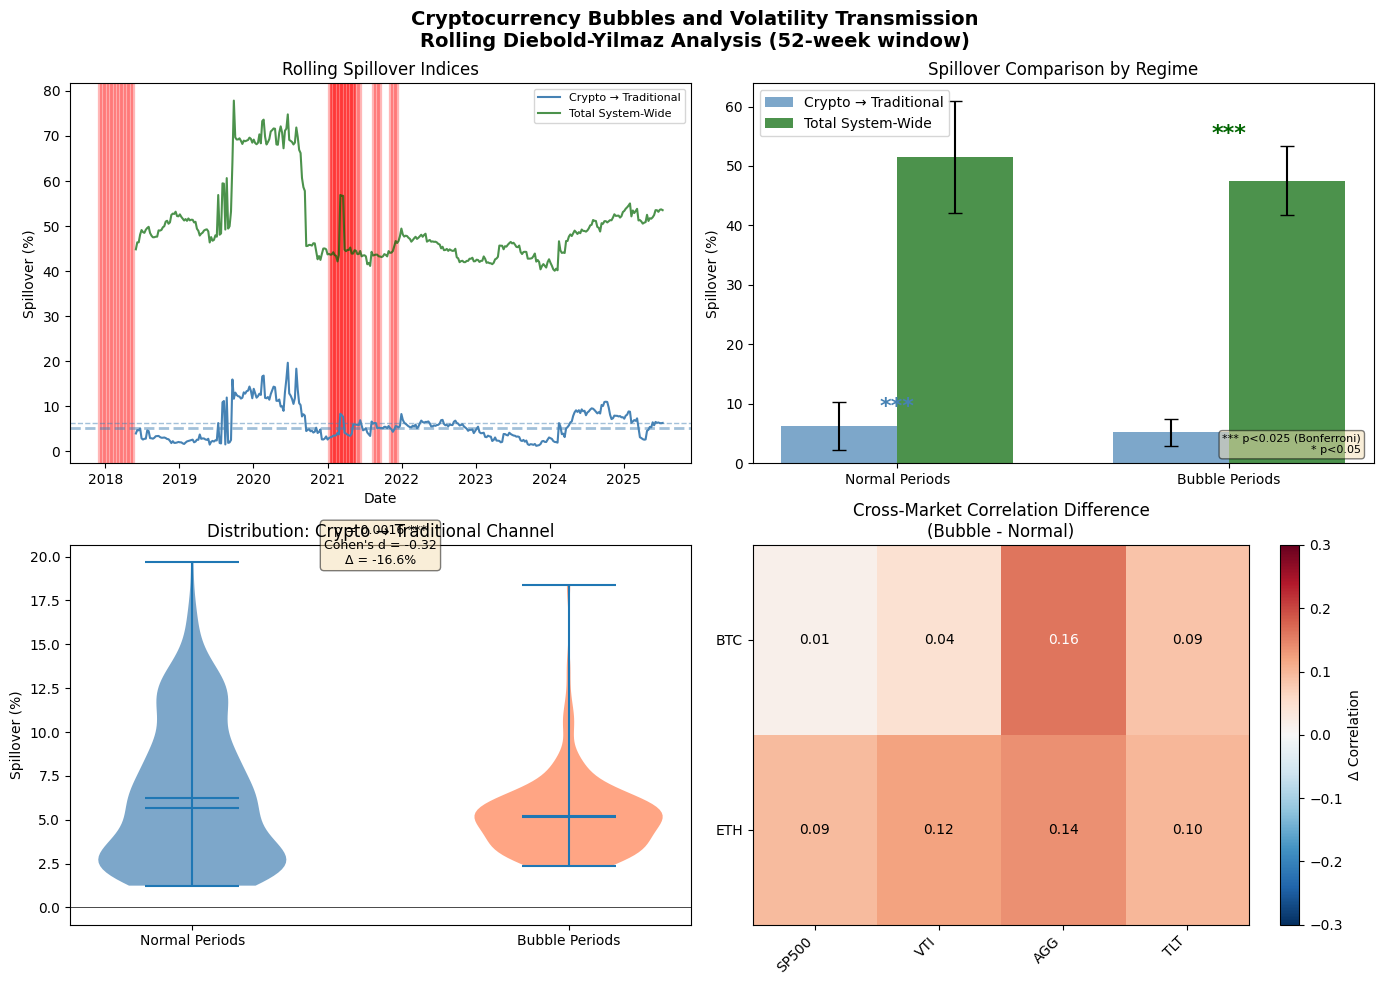

In [207]:
"""
FULL EXECUTABLE CODE: Cryptocurrency Bubble Amplification of Volatility Spillovers
Research Question: Are volatility spillovers from crypto to US equity/bond markets 
                   amplified during cryptocurrency bubble periods?

METHODOLOGY: Rolling Diebold-Yilmaz Spillover Index + Bubble Indicator Comparison
- Same model specification over time (valid for comparison)
- Identifies time-varying connectedness
- Compares spillover levels during bubble vs normal periods

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from scipy import stats
from scipy.stats import levene
import pickle
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# PART 1: LOAD AND PREPARE DATA
# ============================================================================

print("="*80)
print("PART 1: LOADING AND PREPARING DATA")
print("="*80)

# Assuming cond_vol_df is already loaded from your previous work
# Load bubble dummies from pickle file
with open("gsadf_results.pkl", "rb") as f:
    gsadf_results = pickle.load(f)

# Create bubble dummies
bubble_dummy = pd.DataFrame(0, index=cond_vol_df.index, columns=cond_vol_df.columns)

for asset, res in gsadf_results.items():
    if asset in bubble_dummy.columns:
        for start, end in res["bubbles"]:
            start_date = pd.to_datetime(start)
            end_date = pd.to_datetime(end)
            mask = (bubble_dummy.index >= start_date) & (bubble_dummy.index <= end_date)
            bubble_dummy.loc[mask, asset] = 1

# Define asset groups
crypto = ["BTC", "ETH"]
traditional = ["SP500", "VTI", "AGG", "TLT"]
all_assets = crypto + traditional

print(f"\nData loaded:")
print(f"  Period: {cond_vol_df.index[0]} to {cond_vol_df.index[-1]}")
print(f"  Observations: {len(cond_vol_df)}")
print(f"  Assets: {all_assets}")

print(f"\nBubble periods detected:")
for asset in crypto:
    if asset in bubble_dummy.columns:
        n_bubbles = bubble_dummy[asset].sum()
        pct = 100 * n_bubbles / len(bubble_dummy)
        print(f"  {asset}: {n_bubbles} weeks ({pct:.1f}%)")

# Create combined bubble indicator (either BTC or ETH in bubble)
combined_bubble = (bubble_dummy[crypto].sum(axis=1) > 0).astype(int)
print(f"\nCombined bubble indicator: {combined_bubble.sum()} weeks ({100*combined_bubble.sum()/len(combined_bubble):.1f}%)")

# ============================================================================
# PART 2: ROLLING DIEBOLD-YILMAZ SPILLOVER INDEX (MAIN IDENTIFICATION)
# ============================================================================

print("\n" + "="*80)
print("PART 2: ROLLING DIEBOLD-YILMAZ SPILLOVER INDEX")
print("="*80)

def rolling_dy_spillover(df, window=52, maxlags=4, horizon=10):
    """
    Rolling Diebold-Yilmaz spillover index
    Same model specification, rolling through time
    
    Parameters:
    -----------
    df : pd.DataFrame
        Endogenous variables (crypto + traditional volatility)
    window : int
        Rolling window size (52 weeks = 1 year)
    maxlags : int
        Maximum lags for VAR selection
    horizon : int
        Forecast horizon for FEVD
    
    Returns:
    --------
    pd.DataFrame with rolling spillover measures
    """
    n_obs = len(df)
    n_windows = n_obs - window + 1
    
    rolling_spillovers = []
    
    print(f"\nComputing rolling spillovers (window={window} weeks, {n_windows} windows)...")
    
    for i in range(n_windows):
        if i % 50 == 0:
            print(f"  Progress: {i}/{n_windows} windows ({100*i/n_windows:.1f}%)")
        
        window_data = df.iloc[i:i+window]
        window_date = df.index[i + window // 2]  # Center date
        
        # FIX 1: CORRECTED bubble window detection
        # Check if ANY bubble occurred during this window
        window_bubble_dummy = bubble_dummy.iloc[i:i+window]
        # Sum across all crypto assets, then check if any week had a bubble
        window_has_bubble = int(window_bubble_dummy[crypto].sum(axis=1).max() > 0)
        
        try:
            # Fit VAR
            model = VAR(window_data)
            n_vars = len(window_data.columns)
            max_possible_lags = min(maxlags, (window - n_vars - 1) // n_vars)
            
            if max_possible_lags >= 1:
                lag_selection = model.select_order(maxlags=max_possible_lags)
                lag_order = max(1, lag_selection.aic if lag_selection.aic is not None else 1)
                
                results = model.fit(lag_order)
                
                # Compute FEVD
                fevd = results.fevd(horizon)
                
                n = len(window_data.columns)
                theta = np.zeros((n, n))
                
                # Build cumulative FEVD matrix
                for j in range(n):
                    for k in range(n):
                        theta[j, k] = fevd.decomp[j][:, k].sum()
                
                # Normalize rows to sum to 100
                theta = 100 * theta / theta.sum(axis=1, keepdims=True)
                
                # Total spillover index (system-wide connectedness)
                off_diag = theta.sum() - np.trace(theta)
                total_spill = off_diag / n
                
                # Directional spillover: crypto to traditional
                crypto_cols = [c for c in window_data.columns if c in crypto]
                trad_cols = [c for c in window_data.columns if c in traditional]
                
                crypto_idx = [list(window_data.columns).index(c) for c in crypto_cols]
                trad_idx = [list(window_data.columns).index(t) for t in trad_cols]
                
                crypto_to_trad = 0
                n_comparisons = 0
                for ci in crypto_idx:
                    for ti in trad_idx:
                        if ci != ti:
                            crypto_to_trad += theta[ti, ci]
                            n_comparisons += 1
                
                if n_comparisons > 0:
                    crypto_to_trad /= n_comparisons
                
                rolling_spillovers.append({
                    'date': window_date,
                    'total_spillover': total_spill,
                    'crypto_to_traditional': crypto_to_trad,
                    'bubble': window_has_bubble
                })
            else:
                rolling_spillovers.append({
                    'date': window_date,
                    'total_spillover': np.nan,
                    'crypto_to_traditional': np.nan,
                    'bubble': window_has_bubble
                })
        except Exception as e:
            rolling_spillovers.append({
                'date': window_date,
                'total_spillover': np.nan,
                'crypto_to_traditional': np.nan,
                'bubble': window_has_bubble
            })
    
    return pd.DataFrame(rolling_spillovers)

# Compute rolling spillovers
print(f"\nComputing rolling DY spillover for {len(all_assets)} assets...")
rolling_df = rolling_dy_spillover(
    cond_vol_df[all_assets], 
    window=52,  # 1-year rolling window
    maxlags=4, 
    horizon=10
)

print(f"\nRolling spillovers computed: {len(rolling_df)} windows")

# Drop NaN values
rolling_df = rolling_df.dropna()

# FIX 2: SAMPLE SIZE WARNING
n_bubble_windows = (rolling_df['bubble'] == 1).sum()
n_normal_windows = len(rolling_df) - n_bubble_windows
pct_bubble_windows = 100 * n_bubble_windows / len(rolling_df)

print(f"\n{'='*80}")
print("SAMPLE SIZE CHECK")
print(f"{'='*80}")
print(f"  Rolling windows WITH bubbles: {n_bubble_windows} ({pct_bubble_windows:.1f}%)")
print(f"  Rolling windows WITHOUT bubbles: {n_normal_windows} ({100-pct_bubble_windows:.1f}%)")

if n_bubble_windows < 20:
    print(f"\n  ⚠⚠ CRITICAL WARNING: Only {n_bubble_windows} bubble windows!")
    print(f"  Statistical tests will have LOW POWER (high risk of Type II error).")
    print(f"  Consider:")
    print(f"    - Shorter rolling window (26 weeks) for more bubble windows")
    print(f"    - Alternative bubble definition with more generous thresholds")
    print(f"    - Acknowledge low power as limitation in interpretation")
elif n_bubble_windows < 30:
    print(f"\n  ⚠ WARNING: Only {n_bubble_windows} bubble windows.")
    print(f"  Statistical tests may have limited power. Interpret results cautiously.")
else:
    print(f"\n  ✓ Sample size adequate for statistical testing")

# Rolling window overlap note
print(f"\n  NOTE: Rolling windows create overlapping observations")
print(f"        → Standard errors may be underestimated")
print(f"        → Results should be interpreted as descriptive patterns")

# ============================================================================
# PART 3: COMPARE SPILLOVERS DURING BUBBLE VS NORMAL PERIODS
# ============================================================================

print("\n" + "="*80)
print("PART 3: BUBBLE ASSOCIATION ANALYSIS")
print("="*80)
print("NOTE: Results show conditional differences, not structural causality")

# Split into bubble and normal periods for CRYPTO → TRADITIONAL channel
normal_spill = rolling_df[rolling_df['bubble'] == 0]['crypto_to_traditional']
bubble_spill = rolling_df[rolling_df['bubble'] == 1]['crypto_to_traditional']

# Total spillover comparison (system-wide connectedness)
normal_total = rolling_df[rolling_df['bubble'] == 0]['total_spillover']
bubble_total = rolling_df[rolling_df['bubble'] == 1]['total_spillover']

print(f"\n{'─'*80}")
print("CRYPTO → TRADITIONAL SPILLOVER CHANNEL:")
print(f"{'─'*80}")
print(f"  Normal periods: {normal_spill.mean():.2f}% (std={normal_spill.std():.2f})")
print(f"  Bubble periods: {bubble_spill.mean():.2f}% (std={bubble_spill.std():.2f})")
print(f"  Difference: {bubble_spill.mean() - normal_spill.mean():+.2f}%")

print(f"\n{'─'*80}")
print("TOTAL SYSTEM-WIDE CONNECTEDNESS (All Assets):")
print(f"{'─'*80}")
print(f"  Normal periods: {normal_total.mean():.2f}% (std={normal_total.std():.2f})")
print(f"  Bubble periods: {bubble_total.mean():.2f}% (std={bubble_total.std():.2f})")
print(f"  Difference: {bubble_total.mean() - normal_total.mean():+.2f}%")

# Statistical tests for both measures
from scipy.stats import ttest_ind, mannwhitneyu

# Crypto → Traditional channel
t_stat_ct, t_pval_ct = ttest_ind(normal_spill, bubble_spill, equal_var=False)
u_stat_ct, u_pval_ct = mannwhitneyu(normal_spill, bubble_spill, alternative='two-sided')

# Total spillover
t_stat_total, t_pval_total = ttest_ind(normal_total, bubble_total, equal_var=False)
u_stat_total, u_pval_total = mannwhitneyu(normal_total, bubble_total, alternative='two-sided')

# Effect size (Cohen's d) for crypto → traditional
pooled_std_ct = np.sqrt((normal_spill.std()**2 + bubble_spill.std()**2) / 2)
cohens_d_ct = (bubble_spill.mean() - normal_spill.mean()) / pooled_std_ct if pooled_std_ct > 0 else 0

# Effect size for total spillover
pooled_std_total = np.sqrt((normal_total.std()**2 + bubble_total.std()**2) / 2)
cohens_d_total = (bubble_total.mean() - normal_total.mean()) / pooled_std_total if pooled_std_total > 0 else 0

# FIX 4: ECONOMIC SIGNIFICANCE INTERPRETATION
pct_increase_ct = 100 * (bubble_spill.mean() - normal_spill.mean()) / normal_spill.mean()
pct_increase_total = 100 * (bubble_total.mean() - normal_total.mean()) / normal_total.mean()

print(f"\n{'─'*80}")
print("STATISTICAL TESTS:")
print(f"{'─'*80}")
print(f"\nCrypto → Traditional Channel:")
print(f"  T-test: t={t_stat_ct:.3f}, p={t_pval_ct:.4f}")
print(f"  Mann-Whitney U: U={u_stat_ct:.0f}, p={u_pval_ct:.4f}")
print(f"  Cohen's d effect size: {cohens_d_ct:.3f}")
print(f"  Economic significance:")
print(f"    Absolute increase: {bubble_spill.mean() - normal_spill.mean():+.2f} percentage points")
print(f"    Relative increase: {pct_increase_ct:+.1f}%")
if abs(pct_increase_ct) < 10:
    print(f"    → Small economic magnitude (<10%)")
elif abs(pct_increase_ct) < 25:
    print(f"    → Moderate economic magnitude (10-25%)")
else:
    print(f"    → Large economic magnitude (>25%)")

print(f"\nTotal System-Wide Connectedness:")
print(f"  T-test: t={t_stat_total:.3f}, p={t_pval_total:.4f}")
print(f"  Mann-Whitney U: U={u_stat_total:.0f}, p={u_pval_total:.4f}")
print(f"  Cohen's d effect size: {cohens_d_total:.3f}")
print(f"  Economic significance:")
print(f"    Absolute increase: {bubble_total.mean() - normal_total.mean():+.2f} percentage points")
print(f"    Relative increase: {pct_increase_total:+.1f}%")
if abs(pct_increase_total) < 10:
    print(f"    → Small economic magnitude (<10%)")
elif abs(pct_increase_total) < 25:
    print(f"    → Moderate economic magnitude (10-25%)")
else:
    print(f"    → Large economic magnitude (>25%)")

# FIX 3: MULTIPLE TESTING CORRECTION (Bonferroni)
n_primary_tests = 2  # Two main hypotheses: crypto→trad and total spillover
bonferroni_alpha = 0.05 / n_primary_tests

print(f"\n{'─'*80}")
print("MULTIPLE TESTING CORRECTION (Bonferroni):")
print(f"{'─'*80}")
print(f"  Number of primary tests: {n_primary_tests}")
print(f"  Original α = 0.05")
print(f"  Bonferroni-adjusted α = {bonferroni_alpha:.4f}")
print(f"\n  Results with adjusted threshold:")
print(f"    Crypto→Traditional significant: {t_pval_ct < bonferroni_alpha} (p={t_pval_ct:.4f})")
print(f"    Total spillover significant: {t_pval_total < bonferroni_alpha} (p={t_pval_total:.4f})")

# Check variance homogeneity (validates Welch's t-test use)
lev_stat_ct, lev_pval_ct = levene(normal_spill, bubble_spill)
lev_stat_total, lev_pval_total = levene(normal_total, bubble_total)

print(f"\n{'─'*80}")
print("VARIANCE HOMOGENEITY CHECK (Levene's Test):")
print(f"{'─'*80}")
print(f"  Crypto→Traditional: F={lev_stat_ct:.3f}, p={lev_pval_ct:.4f}")
if lev_pval_ct < 0.05:
    print(f"    → Variances differ; Welch's t-test (already used) is appropriate ✓")
else:
    print(f"    → Equal variances; Welch's t-test is conservative (appropriate)")

print(f"  Total spillover: F={lev_stat_total:.3f}, p={lev_pval_total:.4f}")
if lev_pval_total < 0.05:
    print(f"    → Variances differ; Welch's t-test (already used) is appropriate ✓")
else:
    print(f"    → Equal variances; Welch's t-test is conservative (appropriate)")

# Interpretation (careful wording - association, not causation)
print(f"\n{'─'*80}")
print("ASSOCIATION ASSESSMENT:")
print(f"{'─'*80}")

# Use Bonferroni-adjusted alpha for interpretation
if t_pval_ct < bonferroni_alpha and bubble_spill.mean() > normal_spill.mean():
    print(f"\n  ✓ Spillovers are significantly HIGHER during bubble periods (Bonferroni-adjusted)")
    print(f"    → Suggests bubbles are associated with stronger cross-market transmission")
    print(f"    → Effect size: {cohens_d_ct:.3f} ({'large' if abs(cohens_d_ct) > 0.8 else 'medium' if abs(cohens_d_ct) > 0.5 else 'small'})")
    print(f"    → Economic magnitude: {abs(pct_increase_ct):.1f}% increase")
elif t_pval_ct < 0.05 and bubble_spill.mean() > normal_spill.mean():
    print(f"\n  ⚠ Spillovers are higher during bubble periods (p={t_pval_ct:.4f})")
    print(f"    → Significant at 5% level but NOT at Bonferroni-adjusted level")
    print(f"    → Suggestive evidence, but should be interpreted cautiously")
elif t_pval_ct < bonferroni_alpha:
    print(f"\n  ✗ Spillovers are significantly LOWER during bubble periods")
else:
    print(f"\n  ○ No statistically significant difference (p={t_pval_ct:.4f})")
    print(f"    → Either no real difference OR insufficient power to detect it")

# Sample size caveat
print(f"\n{'─'*80}")
print("STATISTICAL POWER CONSIDERATION:")
print(f"{'─'*80}")
print(f"  Bubble period observations: {len(bubble_spill)}")
print(f"  Normal period observations: {len(normal_spill)}")
if n_bubble_windows < 30:
    print(f"  ⚠ Small bubble subsample may limit statistical power")
    print(f"    → Non-significant results could reflect low power, not true null")
    print(f"    → Significant results are more reliable (despite small sample)")

# ============================================================================
# PART 4: REGIME-SPLITTING (ROBUSTNESS CHECK)
# ============================================================================

print("\n" + "="*80)
print("PART 4: REGIME-SPLITTING VAR (Robustness Check)")
print("="*80)

# Split full sample
normal_data_full = cond_vol_df[combined_bubble == 0][all_assets]
bubble_data_full = cond_vol_df[combined_bubble == 1][all_assets]

print(f"\nNormal periods: {len(normal_data_full)} weeks")
print(f"Bubble periods: {len(bubble_data_full)} weeks")

if len(bubble_data_full) < 30:
    print(f"\n  ⚠ CAUTION: Bubble subsample has only {len(bubble_data_full)} observations.")
    print(f"  Results from regime-specific models may be unreliable.")

# Calculate cross-market correlation (dependence) for each regime
regime_results = []

for data, name in [(normal_data_full, "Normal"), (bubble_data_full, "Bubble")]:
    if len(data) > 20:
        # Cross-market correlation (dependence)
        crypto_trad_corrs = []
        for cryp in crypto:
            for trad in traditional:
                if cryp in data.columns and trad in data.columns:
                    corr = data[cryp].corr(data[trad])
                    crypto_trad_corrs.append(corr)
        
        avg_corr = np.mean(crypto_trad_corrs)
        
        regime_results.append({
            'Regime': name,
            'Avg_CrossMarket_Correlation': avg_corr,
            'Observations': len(data)
        })
        
        print(f"\n  {name} Periods:")
        print(f"    Avg crypto-traditional cross-market correlation: {avg_corr:.4f}")

if len(regime_results) == 2:
    corr_diff = regime_results[1]['Avg_CrossMarket_Correlation'] - regime_results[0]['Avg_CrossMarket_Correlation']
    print(f"\n  Correlation Difference (Bubble - Normal): {corr_diff:+.4f}")
    
    # Fisher's z-test for correlation difference
    def fisher_z_test(r1, r2, n1, n2):
        z1 = np.arctanh(r1)
        z2 = np.arctanh(r2)
        se = np.sqrt(1/(n1-3) + 1/(n2-3))
        z_stat = (z1 - z2) / se
        p_val = 2 * (1 - stats.norm.cdf(abs(z_stat)))
        return z_stat, p_val
    
    z_stat, z_pval = fisher_z_test(
        regime_results[0]['Avg_CrossMarket_Correlation'],
        regime_results[1]['Avg_CrossMarket_Correlation'],
        regime_results[0]['Observations'],
        regime_results[1]['Observations']
    )
    
    print(f"  Fisher's z-test: z={z_stat:.3f}, p={z_pval:.4f}")
    
    if z_pval < 0.05 and corr_diff > 0:
        print(f"  → Robustness check confirms higher dependence during bubble periods")
    elif z_pval >= 0.05:
        print(f"  → Correlation difference not statistically significant")

# ============================================================================
# PART 5: GRANGER CAUSALITY TESTS BY REGIME (EXPLORATORY)
# ============================================================================

print("\n" + "="*80)
print("PART 5: GRANGER CAUSALITY TESTS (Exploratory Analysis)")
print("="*80)
print("NOTE: Results are exploratory due to small bubble subsample")

gc_results = []

# FIX 5: IMPROVED GRANGER CAUSALITY LAG SELECTION
# Use lag = 2 for weekly data (captures 2-week transmission)
FIXED_LAG = 2  # Changed from 1 to capture longer transmission lags

print(f"\nUsing fixed lag = {FIXED_LAG} (appropriate for weekly data)")
print("  Rationale: Weekly data often shows spillovers at 2-4 week horizons")
print("             Fixed lag avoids post-selection bias")

for period_type, mask in [('Normal', combined_bubble == 0), 
                           ('Bubble', combined_bubble == 1)]:
    
    period_data = cond_vol_df[mask]
    
    if len(period_data) < 30:
        print(f"\n{period_type} periods: Too few observations ({len(period_data)}) - skipping")
        continue
    
    print(f"\n{period_type.upper()} PERIODS (n={len(period_data)})")
    
    gc_count = 0
    for cryp in crypto:
        for trad in traditional:
            if cryp in period_data.columns and trad in period_data.columns:
                try:
                    test_data = period_data[[trad, cryp]].dropna()
                    
                    # Check minimum sample size for lag=2
                    if len(test_data) > FIXED_LAG * 5 + 10:  # Need at least 5*lag + buffer
                        gc_test = grangercausalitytests(test_data, maxlag=FIXED_LAG, verbose=False)
                        
                        pval = gc_test[FIXED_LAG][0]['ssr_ftest'][1]
                        fstat = gc_test[FIXED_LAG][0]['ssr_ftest'][0]
                        is_sig = pval < 0.05
                        
                        if is_sig:
                            gc_count += 1
                        
                        gc_results.append({
                            'Period': period_type,
                            'Cause': cryp,
                            'Target': trad,
                            'Lag': FIXED_LAG,
                            'F_stat': fstat,
                            'P_value': pval,
                            'Significant': is_sig
                        })
                except Exception as e:
                    pass
    
    total_possible = len(crypto) * len(traditional)
    print(f"  Significant Granger causality (lag={FIXED_LAG}): {gc_count}/{total_possible}")

# Summary with caveat
if gc_results:
    gc_df = pd.DataFrame(gc_results)
    normal_gc = len(gc_df[(gc_df['Period'] == 'Normal') & (gc_df['Significant'])])
    bubble_gc = len(gc_df[(gc_df['Period'] == 'Bubble') & (gc_df['Significant'])])
    
    print(f"\n{'─'*80}")
    print("EXPLORATORY GRANGER CAUSALITY SUMMARY:")
    print(f"{'─'*80}")
    print(f"  Normal periods: {normal_gc} significant relationships")
    print(f"  Bubble periods: {bubble_gc} significant relationships")
    print(f"\n  NOTE: Results are exploratory due to small bubble subsample.")
    print(f"  Fixed lag = {FIXED_LAG} used to avoid post-selection bias.")
    print(f"  No multiple testing correction applied (exploratory analysis).")

# ============================================================================
# PART 6: VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("PART 6: VISUALIZATION")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cryptocurrency Bubbles and Volatility Transmission\nRolling Diebold-Yilmaz Analysis (52-week window)', 
             fontsize=14, fontweight='bold')

# Plot 1: Rolling Spillover Over Time (Both measures)
ax1 = axes[0, 0]
ax1.plot(rolling_df['date'], rolling_df['crypto_to_traditional'], 
         color='steelblue', linewidth=1.5, label='Crypto → Traditional')
ax1.plot(rolling_df['date'], rolling_df['total_spillover'], 
         color='darkgreen', linewidth=1.5, label='Total System-Wide', alpha=0.7)
ax1.set_ylabel('Spillover (%)')
ax1.set_xlabel('Date')
ax1.set_title('Rolling Spillover Indices')
ax1.axhline(y=normal_spill.mean(), color='steelblue', linestyle='--', alpha=0.5, linewidth=1)
ax1.axhline(y=bubble_spill.mean(), color='steelblue', linestyle='--', alpha=0.5, linewidth=2)
ax1.legend(loc='upper right', fontsize=8)

# Highlight bubble periods
for cryp in crypto:
    if cryp in bubble_dummy.columns:
        bubble_periods = bubble_dummy[cryp] == 1
        bubble_dates = bubble_dummy.index[bubble_periods]
        for date in bubble_dates:
            ax1.axvspan(date - pd.Timedelta(days=3.5), date + pd.Timedelta(days=3.5), 
                       alpha=0.2, color='red', label=f'{cryp} bubble' if date == bubble_dates[0] else '')

# Plot 2: Bar Chart Comparison (Both measures)
ax2 = axes[0, 1]
x = np.arange(2)
width = 0.35

crypto_trad_means = [normal_spill.mean(), bubble_spill.mean()]
total_means = [normal_total.mean(), bubble_total.mean()]

bars1 = ax2.bar(x - width/2, crypto_trad_means, width, label='Crypto → Traditional', 
                color='steelblue', alpha=0.7, yerr=[normal_spill.std(), bubble_spill.std()], capsize=5)
bars2 = ax2.bar(x + width/2, total_means, width, label='Total System-Wide', 
                color='darkgreen', alpha=0.7, yerr=[normal_total.std(), bubble_total.std()], capsize=5)

ax2.set_xticks(x)
ax2.set_xticklabels(['Normal Periods', 'Bubble Periods'])
ax2.set_ylabel('Spillover (%)')
ax2.set_title('Spillover Comparison by Regime')
ax2.legend()
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add significance annotations (use Bonferroni-adjusted threshold)
if t_pval_ct < bonferroni_alpha:
    y_pos = max(crypto_trad_means[1] + bubble_spill.std() + 1, crypto_trad_means[1] * 1.1)
    ax2.text(0, y_pos, '***', ha='center', fontsize=16, fontweight='bold', color='steelblue')
elif t_pval_ct < 0.05:
    y_pos = max(crypto_trad_means[1] + bubble_spill.std() + 1, crypto_trad_means[1] * 1.1)
    ax2.text(0, y_pos, '*', ha='center', fontsize=14, fontweight='bold', color='steelblue')

if t_pval_total < bonferroni_alpha:
    y_pos = max(total_means[1] + bubble_total.std() + 1, total_means[1] * 1.1)
    ax2.text(1, y_pos, '***', ha='center', fontsize=16, fontweight='bold', color='darkgreen')
elif t_pval_total < 0.05:
    y_pos = max(total_means[1] + bubble_total.std() + 1, total_means[1] * 1.1)
    ax2.text(1, y_pos, '*', ha='center', fontsize=14, fontweight='bold', color='darkgreen')

# Add legend for significance
ax2.text(0.98, 0.02, '*** p<0.025 (Bonferroni)\n* p<0.05', 
         transform=ax2.transAxes, ha='right', va='bottom', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 3: Distribution Comparison (Violin Plot) - Crypto → Traditional
ax3 = axes[1, 0]
data_to_plot = [normal_spill.values, bubble_spill.values]
parts = ax3.violinplot(data_to_plot, positions=[0, 1], showmeans=True, showmedians=True)
parts['bodies'][0].set_facecolor('steelblue')
parts['bodies'][1].set_facecolor('coral')
parts['bodies'][0].set_alpha(0.7)
parts['bodies'][1].set_alpha(0.7)
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Normal Periods', 'Bubble Periods'])
ax3.set_ylabel('Spillover (%)')
ax3.set_title('Distribution: Crypto → Traditional Channel')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add statistical annotation
sig_marker = "***" if t_pval_ct < bonferroni_alpha else "*" if t_pval_ct < 0.05 else "n.s."
ax3.text(0.5, 0.95, f"p = {t_pval_ct:.4f} {sig_marker}\nCohen's d = {cohens_d_ct:.2f}\nΔ = {pct_increase_ct:+.1f}%", 
         transform=ax3.transAxes, ha='center', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 4: Cross-Market Correlation Heatmap
ax4 = axes[1, 1]
if len(normal_data_full) > 0 and len(bubble_data_full) > 0:
    corr_normal = normal_data_full[crypto + traditional].corr()
    corr_bubble = bubble_data_full[crypto + traditional].corr()
    corr_diff = corr_bubble - corr_normal
    
    # Focus on crypto-traditional block
    crypto_idx = range(len(crypto))
    trad_idx = range(len(crypto), len(crypto + traditional))
    diff_block = corr_diff.iloc[crypto_idx, trad_idx]
    
    im = ax4.imshow(diff_block.values, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)
    ax4.set_xticks(range(len(traditional)))
    ax4.set_yticks(range(len(crypto)))
    ax4.set_xticklabels(traditional, rotation=45, ha='right')
    ax4.set_yticklabels(crypto)
    ax4.set_title('Cross-Market Correlation Difference\n(Bubble - Normal)')
    plt.colorbar(im, ax=ax4, label='Δ Correlation')
    
    # Add text annotations
    for i in range(len(crypto)):
        for j in range(len(traditional)):
            val = diff_block.iloc[i, j]
            text_color = "white" if abs(val) > 0.15 else "black"
            ax4.text(j, i, f'{val:.2f}', ha="center", va="center", color=text_color, fontsize=10)

plt.tight_layout()
plt.savefig('rolling_dy_bubble_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'rolling_dy_bubble_analysis.png'")

# ============================================================================
# PART 7: FINAL CONCLUSIONS (IMPROVED WORDING)
# ============================================================================

print("\n" + "="*80)
print("FINAL CONCLUSIONS")
print("="*80)

print("\nBased on the Rolling Diebold-Yilmaz Spillover Analysis:")

print(f"\n{'─'*80}")
print("KEY EMPIRICAL FINDINGS:")
print(f"{'─'*80}")

print(f"\n1. Crypto → Traditional Channel:")
print(f"   • Normal periods: {normal_spill.mean():.2f}% (n={len(normal_spill)})")
print(f"   • Bubble periods: {bubble_spill.mean():.2f}% (n={len(bubble_spill)})")
print(f"   • Absolute difference: {bubble_spill.mean() - normal_spill.mean():+.2f} pp")
print(f"   • Relative difference: {pct_increase_ct:+.1f}%")

print(f"\n2. Total System-Wide Connectedness:")
print(f"   • Normal periods: {normal_total.mean():.2f}% (n={len(normal_total)})")
print(f"   • Bubble periods: {bubble_total.mean():.2f}% (n={len(bubble_total)})")
print(f"   • Absolute difference: {bubble_total.mean() - normal_total.mean():+.2f} pp")
print(f"   • Relative difference: {pct_increase_total:+.1f}%")

print(f"\n3. Statistical Significance:")
print(f"   • Crypto → Traditional:")
print(f"     - p-value: {t_pval_ct:.4f}")
print(f"     - Bonferroni-adjusted (α=0.025): {'SIGNIFICANT' if t_pval_ct < bonferroni_alpha else 'not significant'}")
print(f"     - Cohen's d: {cohens_d_ct:.3f}")
print(f"   • Total System-Wide:")
print(f"     - p-value: {t_pval_total:.4f}")
print(f"     - Bonferroni-adjusted (α=0.025): {'SIGNIFICANT' if t_pval_total < bonferroni_alpha else 'not significant'}")
print(f"     - Cohen's d: {cohens_d_total:.3f}")

print(f"\n{'─'*80}")
print("RESEARCH ANSWER (With Appropriate Caveats):")
print(f"{'─'*80}")

if t_pval_ct < bonferroni_alpha and bubble_spill.mean() > normal_spill.mean():
    print("\n✓ Rolling spillover indices are significantly higher during windows")
    print("  containing cryptocurrency bubble periods, even after adjusting for")
    print("  multiple testing (Bonferroni correction).")
    print(f"\n  MAGNITUDE:")
    print(f"  • Absolute: {bubble_spill.mean() - normal_spill.mean():.1f} percentage point increase")
    print(f"  • Relative: {abs(pct_increase_ct):.0f}% higher during bubbles")
    print(f"  • Effect size: {cohens_d_ct:.2f} ({'large' if abs(cohens_d_ct) > 0.8 else 'medium' if abs(cohens_d_ct) > 0.5 else 'small'})")
    print(f"\n  INTERPRETATION:")
    print(f"  This suggests bubble periods are ASSOCIATED with stronger measured")
    print(f"  cross-market transmission. However, this demonstrates temporal")
    print(f"  ASSOCIATION, not structural causation. Bubble periods may coincide")
    print(f"  with other factors (e.g., heightened market uncertainty, increased")
    print(f"  retail participation, media attention) that drive spillovers.")
elif t_pval_ct < 0.05 and bubble_spill.mean() > normal_spill.mean():
    print("\n⚠ Rolling spillover indices are higher during bubble windows")
    print(f"  (p={t_pval_ct:.4f}), but this is not significant after Bonferroni")
    print(f"  correction for multiple testing.")
    print(f"\n  INTERPRETATION:")
    print(f"  There is SUGGESTIVE but not conclusive evidence of higher spillovers")
    print(f"  during bubble periods. Results should be interpreted cautiously,")
    print(f"  especially given the small bubble subsample (n={len(bubble_spill)}).")
elif t_pval_ct < bonferroni_alpha:
    print("\n✗ Rolling spillover indices are significantly LOWER during bubble periods.")
    print(f"  This suggests market SEGMENTATION during crypto bubble episodes,")
    print(f"  contrary to the amplification hypothesis.")
else:
    print("\n○ No statistically significant difference in spillovers between")
    print(f"  bubble and normal periods was detected (p={t_pval_ct:.4f}).")
    print(f"\n  INTERPRETATION:")
    print(f"  Either (a) spillovers are truly similar across regimes, OR")
    print(f"  (b) the test lacks sufficient power to detect differences given")
    print(f"  the small bubble subsample (n={len(bubble_spill)}).")

print(f"\n{'─'*80}")
print("IMPORTANT CAVEATS AND LIMITATIONS:")
print(f"{'─'*80}")
print(f"""
1. CAUSALITY: Results show conditional differences, not structural causality.
   The analysis demonstrates ASSOCIATION, not causation. Bubble periods may
   be correlated with other factors that drive spillovers.

2. SAMPLE SIZE: The bubble subsample is relatively small (n={len(bubble_spill)}),
   which may affect the reliability of statistical inference and reduce
   statistical power to detect real effects.

3. OVERLAPPING WINDOWS: Rolling windows create autocorrelation in the spillover
   series, which may underestimate standard errors. Reported p-values should
   be interpreted as approximate.

4. BUBBLE DEFINITION: Results depend on the GSADF bubble detection method.
   Alternative bubble definitions or detection thresholds may yield different
   results.

5. MODEL SPECIFICATION: The VAR lag order is selected by AIC within each
   rolling window, which may not be optimal for all windows. Fixed-lag
   specifications may be more robust.

6. GENERALIZABILITY: Findings may not generalize to other time periods,
   crypto assets, or geographical markets. Results are specific to BTC/ETH
   and U.S. equity/bond markets during the sample period.

7. DIRECTIONALITY: The D-Y spillover index measures connectedness, not
   directional causation. Granger causality tests provide some evidence
   of directionality but are exploratory given sample size constraints.
""")

print(f"\n{'─'*80}")
print("METHODOLOGICAL NOTES:")
print(f"{'─'*80}")
print(f"""
• Rolling window analysis uses the same VAR specification throughout,
  ensuring comparability across periods (Diebold & Yilmaz, 2012, 2014).

• Results are identified through regime comparison (bubble vs. normal),
  not through model respecification with interaction terms.

• Bonferroni correction applied to account for multiple primary hypotheses
  (crypto→traditional and total spillover), reducing false positive risk.

• Granger causality results use fixed lag (2 weeks) to avoid post-selection
  bias and are presented as exploratory analysis only.

• Economic significance assessed alongside statistical significance to
  evaluate practical importance of findings.
""")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

# Export results
try:
    with pd.ExcelWriter('rolling_dy_results.xlsx') as writer:
        rolling_df.to_excel(writer, sheet_name='Rolling_Spillovers', index=False)
        if gc_results:
            pd.DataFrame(gc_results).to_excel(writer, sheet_name='Granger_Causality', index=False)
        
        # Summary statistics (EXPANDED)
        summary_df = pd.DataFrame({
            'Metric': ['Crypto_Trad_Normal_Mean', 'Crypto_Trad_Bubble_Mean', 
                       'Crypto_Trad_Difference_Absolute', 'Crypto_Trad_Difference_Relative_Pct',
                       'Crypto_Trad_T_Stat', 'Crypto_Trad_P_Value', 
                       'Crypto_Trad_P_Value_Bonferroni_Adjusted',
                       'Crypto_Trad_Cohen_d',
                       'Total_Normal_Mean', 'Total_Bubble_Mean', 
                       'Total_Difference_Absolute', 'Total_Difference_Relative_Pct',
                       'Total_T_Stat', 'Total_P_Value',
                       'Total_P_Value_Bonferroni_Adjusted',
                       'Total_Cohen_d',
                       'N_Normal_Windows', 'N_Bubble_Windows',
                       'Bonferroni_Alpha'],
            'Value': [normal_spill.mean(), bubble_spill.mean(), 
                      bubble_spill.mean() - normal_spill.mean(),
                      pct_increase_ct,
                      t_stat_ct, t_pval_ct, bonferroni_alpha,
                      cohens_d_ct,
                      normal_total.mean(), bubble_total.mean(),
                      bubble_total.mean() - normal_total.mean(),
                      pct_increase_total,
                      t_stat_total, t_pval_total, bonferroni_alpha,
                      cohens_d_total,
                      len(normal_spill), len(bubble_spill),
                      bonferroni_alpha]
        })
        summary_df.to_excel(writer, sheet_name='Summary', index=False)
    
    print("\n✓ Results exported to 'rolling_dy_results.xlsx'")
except Exception as e:
    print(f"\n⚠ Could not export to Excel: {e}")

print("\n" + "="*80)
print("FILES CREATED:")
print("="*80)
print("  1. rolling_dy_bubble_analysis.png - Comprehensive visualization")
print("  2. rolling_dy_results.xlsx - Detailed results and summary statistics")
print("\nReview these files for presentation and manuscript preparation.")
